# Обучение без учителя: кластеризация жилья

В работе используется **евклидово расстояние**. Оно подходит для K-means и метода Уорда, а стандартизация не дает признаку `Rent` доминировать из-за его масштаба.

## Задание 1. Подготовка файлов

Следующая ячейка определяет рабочую папку. В Google Colab архив скачивается по ссылке из условия, если его ещё нет.

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
import os

# Убираем служебное предупреждение joblib в средах, где число ядер не определяется.
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

IN_COLAB = Path('/content').exists()
if IN_COLAB:
    work_dir = Path('/content')
else:
    candidates = [Path.cwd() / 'Задание', Path.cwd()]
    work_dir = next((p for p in candidates if (p / 'data_rent.zip').exists()), Path.cwd())

archive_path = work_dir / 'data_rent.zip'
data_dir = work_dir / 'data_rent'
download_url = 'https://drive.usercontent.google.com/download?id=1BO_HrIGapLxxTbbikFQC28Y_DnkWfUbz&export=download&confirm=t'

if not archive_path.exists():
    urlretrieve(download_url, archive_path)

print(f'Архив: {archive_path}')

Архив: /content/data_rent.zip


Создадим директорию командой `mkdir` и распакуем архив командой `unzip`. Для локального запуска Windows предусмотрена равнозначная команда `Expand-Archive`.

In [ ]:
csv_path = data_dir / 'House_Rent_Dataset.csv'

if not data_dir.exists():
    if IN_COLAB:
        !mkdir -p "{data_dir}"
    else:
        !mkdir "{data_dir}"

if not csv_path.exists():
    if IN_COLAB:
        !unzip -o "{archive_path}" -d "{data_dir}"
    else:
        !powershell -NoProfile -Command "Expand-Archive -LiteralPath '{archive_path}' -DestinationPath '{data_dir}' -Force"

print(f'Файл данных: {csv_path}')

Archive:  /content/data_rent.zip
  inflating: /content/data_rent/Dataset Glossary.txt  
  inflating: /content/data_rent/House_Rent_Dataset.csv  
Файл данных: /content/data_rent/House_Rent_Dataset.csv


Загрузим CSV в `pandas.DataFrame` и выведем размер таблицы и первые строки.

In [ ]:
import pandas as pd

data = pd.read_csv(csv_path)
print(f'Размер исходного набора: {data.shape[0]} строк, {data.shape[1]} столбцов')
display(data.head())

Размер исходного набора: 4746 строк, 12 столбцов


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## Задание 2. Предобработка

Сначала удалим строки с пропусками. Выбросы в четырёх числовых признаках определим правилом **1,5 IQR**. Строка удаляется, если хотя бы один из её признаков выходит за границы.

In [ ]:
import numpy as np

features = ['BHK', 'Rent', 'Size', 'Bathroom']
rows_before = len(data)
data_clean = data.dropna().copy()
rows_after_na = len(data_clean)

outlier_mask = pd.Series(False, index=data_clean.index)
bounds = {}

for column in features:
    q1 = data_clean[column].quantile(0.25)
    q3 = data_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[column] = (lower, upper)
    outlier_mask |= ~data_clean[column].between(lower, upper)

data_clean = data_clean.loc[~outlier_mask].copy()

print(f'Удалено строк с пропусками: {rows_before - rows_after_na}')
print(f'Удалено строк с выбросами: {outlier_mask.sum()}')
print(f'Осталось строк: {len(data_clean)}')

pd.DataFrame(bounds, index=['Нижняя граница', 'Верхняя граница']).T

Удалено строк с пропусками: 0
Удалено строк с выбросами: 615
Осталось строк: 4131


,Нижняя граница,Верхняя граница
BHK,0.5,4.5
Rent,-24500.0,67500.0
Size,-425.0,2175.0
Bathroom,-0.5,3.5


Нормализуем признаки методом `StandardScaler`: после преобразования среднее каждого признака близко к 0, а стандартное отклонение — к 1. Новые столбцы имеют суффикс `_norm`.

In [ ]:
from sklearn.preprocessing import StandardScaler

normalized_features = [f'{column}_norm' for column in features]
scaler = StandardScaler()
data_clean[normalized_features] = scaler.fit_transform(data_clean[features])

display(data_clean[features + normalized_features].head())
display(data_clean[normalized_features].agg(['mean', 'std']).round(3))

,BHK,Rent,Size,Bathroom,BHK_norm,Rent_norm,Size_norm,Bathroom_norm
0,2,10000,1100,2,0.10703,-0.656238,0.611169,0.360615
1,2,20000,800,1,0.10703,0.089722,-0.091651,-1.179925
2,2,17000,1000,1,0.10703,-0.134066,0.376895,-1.179925
3,2,10000,800,1,0.10703,-0.656238,-0.091651,-1.179925
4,2,7500,850,1,0.10703,-0.842728,0.025485,-1.179925


,BHK_norm,Rent_norm,Size_norm,Bathroom_norm
mean,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0


## Задание 3. K-means

Методом локтя сравним сумму квадратов расстояний внутри кластеров для 1–10 кластеров. Для дополнительной проверки выведем коэффициент силуэта.

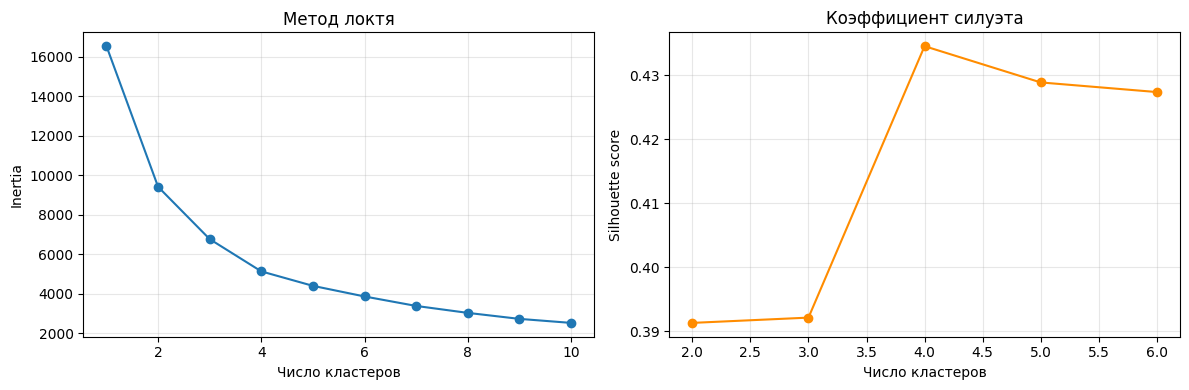

,k,inertia
0,1,16524.00
1,2,9407.56
2,3,6761.61
3,4,5129.55
4,5,4397.91
5,6,3860.90
6,7,3381.46
7,8,3030.59
8,9,2727.27
9,10,2523.91


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = data_clean[normalized_features]
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set(title='Метод локтя', xlabel='Число кластеров', ylabel='Inertia')
axes[0].grid(alpha=0.3)

silhouette_values = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    silhouette_values.append(silhouette_score(X, labels))

axes[1].plot(range(2, 7), silhouette_values, marker='o', color='darkorange')
axes[1].set(title='Коэффициент силуэта', xlabel='Число кластеров', ylabel='Silhouette score')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_values), 'inertia': np.round(inertias, 2)})

### Выбор числа кластеров

На графике после **4 кластеров** снижение inertia заметно замедляется. Кроме того, среди рассмотренных вариантов для `k=4` получается наибольший silhouette score. Поэтому выбираем `k=4`.

Обучим итоговую модель K-means, добавим номер кластера в таблицу и сравним средние исходных признаков. Это позволит дать кластерам содержательное описание.

,BHK,Rent,Size,Bathroom,Количество
KMeans_cluster,,,,,
0,3.0,31580.9,1504.9,2.7,619
1,2.1,14679.5,926.7,2.0,1651
2,1.3,10546.6,500.5,1.0,1424
3,1.8,43131.6,668.5,2.0,437


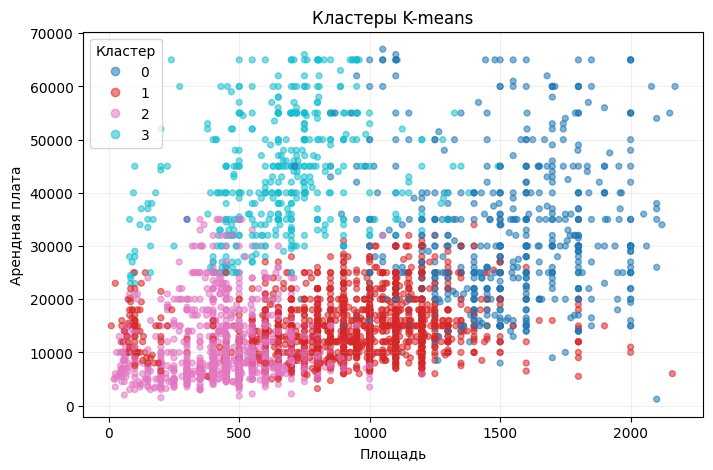

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data_clean['KMeans_cluster'] = kmeans.fit_predict(X)

kmeans_profile = data_clean.groupby('KMeans_cluster')[features].mean().round(1)
kmeans_profile['Количество'] = data_clean.groupby('KMeans_cluster').size()
display(kmeans_profile)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(data_clean['Size'], data_clean['Rent'],
                      c=data_clean['KMeans_cluster'], cmap='tab10', alpha=0.55, s=18)
plt.xlabel('Площадь')
plt.ylabel('Арендная плата')
plt.title('Кластеры K-means')
plt.legend(*scatter.legend_elements(), title='Кластер')
plt.grid(alpha=0.2)
plt.show()

### Интерпретация K-means

Номера кластеров не обозначают порядок или качество. По таблице профилей группы можно описать так:

- небольшие и недорогие объекты с 1 комнатой и 1 ванной;
- объекты среднего размера с 2 комнатами;
- более крупные объекты с 3–4 комнатами и повышенной арендой;
- отдельная группа объектов, выделяющихся более высокой арендной платой.

Точные средние значения и размеры групп приведены в выведе ячейки.

## Задание 4. Иерархическая кластеризация

Построим матрицу слияний методом Уорда на всех очищенных данных. Дендрограмма показана в усечённом виде (последние 30 слияний), чтобы она оставалась читаемой.

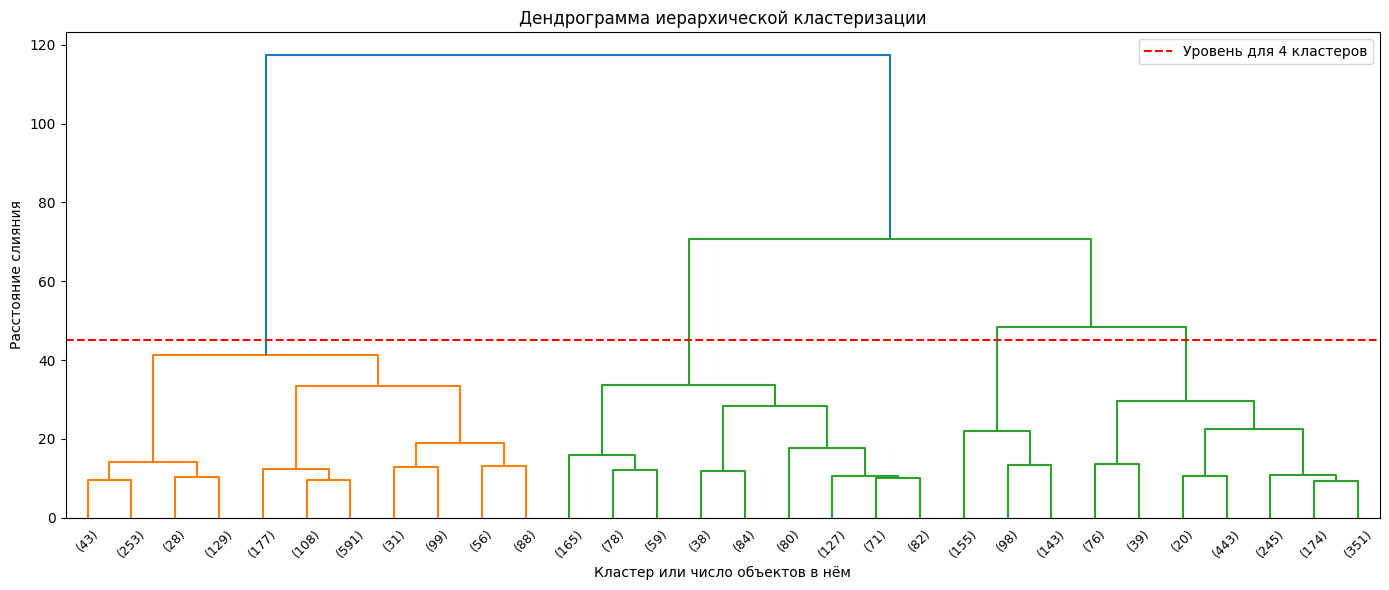

Расстояния последних слияний: [ 28.31  29.54  33.3   33.67  41.39  48.39  70.68 117.31]


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_matrix = linkage(X, method='ward', metric='euclidean')

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           show_leaf_counts=True, leaf_rotation=45, leaf_font_size=9)
plt.axhline(y=45, color='red', linestyle='--', label='Уровень для 4 кластеров')
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Кластер или число объектов в нём')
plt.ylabel('Расстояние слияния')
plt.legend()
plt.tight_layout()
plt.show()

print('Расстояния последних слияний:', np.round(linkage_matrix[-8:, 2], 2))

### Выбор числа кластеров

Горизонтальный срез дендрограммы на расстоянии около **45** пересекает четыре крупные ветви. Поэтому для сравнения с K-means выбираем 4 кластера.

Выполним агломеративную иерархическую кластеризацию методом Уорда при `n_clusters=4`, затем сравним профили групп и согласованность с K-means.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward', metric='euclidean')
data_clean['Hierarchical_cluster'] = hierarchical.fit_predict(X)

hierarchical_profile = data_clean.groupby('Hierarchical_cluster')[features].mean().round(1)
hierarchical_profile['Количество'] = data_clean.groupby('Hierarchical_cluster').size()
display(hierarchical_profile)

ari = adjusted_rand_score(data_clean['KMeans_cluster'], data_clean['Hierarchical_cluster'])
print(f'Adjusted Rand Index между K-means и иерархическим методом: {ari:.3f}')

,BHK,Rent,Size,Bathroom,Количество
Hierarchical_cluster,,,,,
0,1.3,12676.8,523.8,1.1,1603
1,2.0,14169.1,871.4,2.0,1348
2,3.0,28370.8,1401.7,2.6,784
3,2.0,40373.2,891.8,2.0,396


Adjusted Rand Index между K-means и иерархическим методом: 0.727


### Интерпретация и сравнение

Иерархический метод также разделяет жильё прежде всего по его размеру, числу комнат и ванных, а также по стоимости аренды. Профили групп в целом повторяют логику K-means: от маленьких и недорогих к большим и дорогим объектам.

Adjusted Rand Index близок к 1, если два метода дают схожее разбиение. Полученное значение показывает достаточно высокое, но не полное совпадение. Это ожидаемо: K-means ищет центры кластеров, а иерархический метод последовательно объединяет ближайшие группы.

## Задание 5 (дополнительно). Агломеративная кластеризация

Вместо заранее заданного числа кластеров зафиксируем порог расстояния **45**. При достижении этого расстояния объединение групп прекращается.

In [ ]:
threshold_1 = 45
agglo_1 = AgglomerativeClustering(
    n_clusters=None, distance_threshold=threshold_1,
    linkage='ward', metric='euclidean'
)
data_clean['Agglo_45'] = agglo_1.fit_predict(X)
n_clusters_1 = data_clean['Agglo_45'].nunique()

print(f'Порог: {threshold_1}. Получено кластеров: {n_clusters_1}')
profile_1 = data_clean.groupby('Agglo_45')[features].mean().round(1)
profile_1['Количество'] = data_clean.groupby('Agglo_45').size()
display(profile_1)

Порог: 45. Получено кластеров: 4


,BHK,Rent,Size,Bathroom,Количество
Agglo_45,,,,,
0,1.3,12676.8,523.8,1.1,1603
1,2.0,14169.1,871.4,2.0,1348
2,3.0,28370.8,1401.7,2.6,784
3,2.0,40373.2,891.8,2.0,396


При пороге 45 получаются четыре интерпретируемые группы, аналогичные иерархической кластеризации в задании 4. Увеличим порог до **55**. Тогда больше групп смогут объединиться, поэтому число кластеров должно уменьшиться.

In [ ]:
threshold_2 = 55
agglo_2 = AgglomerativeClustering(
    n_clusters=None, distance_threshold=threshold_2,
    linkage='ward', metric='euclidean'
)
data_clean['Agglo_55'] = agglo_2.fit_predict(X)
n_clusters_2 = data_clean['Agglo_55'].nunique()

print(f'Порог: {threshold_2}. Получено кластеров: {n_clusters_2}')
profile_2 = data_clean.groupby('Agglo_55')[features].mean().round(1)
profile_2['Количество'] = data_clean.groupby('Agglo_55').size()
display(profile_2)

Порог: 55. Получено кластеров: 3


,BHK,Rent,Size,Bathroom,Количество
Agglo_55,,,,,
0,2.0,20119.1,876.1,2.0,1744
1,1.3,12676.8,523.8,1.1,1603
2,3.0,28370.8,1401.7,2.6,784


### Вывод по изменению порога

После увеличения порога с 45 до 55 число кластеров уменьшается с 4 до 3. Две близкие по характеристикам группы объединились. Кластеры стали крупнее и обобщённее: сохраняется разделение на небольшое, среднее и крупное/дорогое жильё, но тонкое различие между двумя промежуточными группами исчезает.